# 03 — Strategy comparison: trend, momentum, mean reversion, and breakouts

This notebook is written as a guided lesson. It compares several simple strategies using exactly the same data, costs, timing convention, and evaluation metrics. The point is not to find a magical winner. The point is to learn how different ideas behave, how a backtest can fool us, and how to write down a conclusion that survives skeptical review.

> Educational research only. Nothing here is financial advice or a recommendation to trade.

## How to read a backtest

A backtest is a replay of history using rules that were known in advance. On each day:

1. We observe the price history available at the end of today.
2. A strategy turns that history into a target position: `1` means fully long, `0` means in cash.
3. We delay that position by one trading day. This is the key look-ahead safeguard: today’s closing price cannot be used to earn today’s closing-to-closing return.
4. We apply the next return, subtract a cost for changing exposure, and update the equity curve.

A **signal** is the rule’s opinion. A **position** is the amount of the asset held. **Turnover** measures how much that position changes. **Drawdown** measures how far the portfolio is below its previous peak. The Sharpe ratio summarizes return per unit of volatility, but it is not a guarantee and should never be read without the return, drawdown, costs, and benchmark columns.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.backtest import (
    moving_average_signal,
    run_backtest,
    split_time_series,
    volatility_target_position,
)
from src.data import load_price_data, make_demo_ohlcv
from src.plots import monthly_returns, plot_drawdown
from src.research import comparison_table, metrics_for_period
from src.strategies import (
    bollinger_mean_reversion_signal,
    donchian_breakout_signal,
    time_series_momentum_signal,
)

## Data and assumptions

We use adjusted daily SPY prices from Yahoo Finance. Adjusted prices account for distributions and splits in the downloaded price history, which makes a buy-and-hold comparison more meaningful. This is still not point-in-time institutional data: Yahoo Finance is convenient for education, not a guarantee of perfect historical data.

The default cost is 10 basis points per unit of absolute exposure change. If exposure changes from 0 to 1, the model charges 10 bps. If it changes from 1 to 0, it charges another 10 bps. The cost model is intentionally simple, so the cost-sensitivity section tests whether the conclusion depends on that assumption.

In [2]:
USE_DEMO_DATA = False
TRANSACTION_COST_BPS = 10
if USE_DEMO_DATA:
    prices = make_demo_ohlcv(periods=2_000, seed=11)
else:
    try:
        prices = load_price_data('SPY', '2010-01-01', '2026-01-01')
    except Exception as exc:
        print(f'Live download unavailable ({type(exc).__name__}: {exc}); using deterministic demo data.')
        prices = make_demo_ohlcv(periods=2_000, seed=11)

splits = split_time_series(prices, train_fraction=0.60, validation_fraction=0.20)
print(f'Data: {prices.index.min().date()} through {prices.index.max().date()} ({len(prices):,} trading days)')
print({name: (part.index.min().date(), part.index.max().date(), len(part)) for name, part in splits.items()})

Data: 2010-01-04 through 2025-12-31 (4,024 trading days)
{'train': (datetime.date(2010, 1, 4), datetime.date(2019, 8, 6), 2414), 'validation': (datetime.date(2019, 8, 7), datetime.date(2022, 10, 14), 805), 'test': (datetime.date(2022, 10, 17), datetime.date(2025, 12, 31), 805)}


## The five strategy ideas

| Strategy | Plain-English idea | Main risk |
|---|---|---|
| Buy and hold | Stay invested and accept the market path. | Large drawdowns. |
| Moving-average crossover | Participate when a fast average rises above a slow average. | Whipsaws and late entries. |
| Time-series momentum | Go long when the asset’s trailing return is positive. | It can miss sudden reversals. |
| Bollinger mean reversion | Buy an unusually low price and wait for a move back toward its average. | A cheap-looking price can keep falling. |
| Donchian breakout | Buy a new high and exit after a later downside channel break. | False breakouts in sideways markets. |

The first three trend/momentum rules are related but not identical. The Bollinger rule expresses a different hypothesis: prices sometimes move away from a recent average and then return. The Donchian rule does not predict a reversal; it waits for evidence that a trend is already underway.

### Where these ideas came from

- [Moskowitz, Ooi, and Pedersen’s Time Series Momentum paper](https://w4.stern.nyu.edu/facdir/lpederse/papers/TimeSeriesMomentum.pdf) documents time-series momentum across liquid futures markets and horizons. Our SPY experiment is a simplified educational adaptation, not a replication of that paper.
- [Hurst, Ooi, and Pedersen’s century of trend-following evidence](https://papers.ssrn.com/sol3/Delivery.cfm/SSRN_ID2993026_code277060.pdf?abstractid=2993026&mirid=1&type=2) studies long-run trend following across markets. It motivates testing the idea across regimes, not assuming every asset or period will work.
- [John Bollinger’s official explanation](https://www.bollingerbands.com/bollinger-bands) describes bands as a way to define relative highs and lows using a central tendency and volatility.
- The [Donchian channel documentation](https://www.sequoiadirect.com.au/support/software-documentation/donchian-channel/) defines the channel from prior highs and lows. We use a long-only entry/exit version rather than claiming to reproduce a historical trading system.
- [Bailey, Borwein, López de Prado, and Zhu on backtest overfitting](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2308659) explain why trying many configurations can produce an impressive result by chance. That is why the test period below is not used for parameter selection.

In [3]:
close = prices['close']
buy_and_hold_target = pd.Series(1.0, index=prices.index, name='target_position')
ma_signal = moving_average_signal(close, fast_window=50, slow_window=200)
momentum_signal = time_series_momentum_signal(close, lookback=126, long_only=True)
mean_reversion_signal = bollinger_mean_reversion_signal(close, window=20, num_std=2.0)
breakout_signal = donchian_breakout_signal(
    close, high=prices['high'], low=prices['low'], entry_window=100, exit_window=50
)
volatility_target = volatility_target_position(
    close, ma_signal, target_volatility=0.15, volatility_window=20, max_leverage=1.0
)

results = {
    'Buy and hold': run_backtest(close, buy_and_hold_target, transaction_cost_bps=TRANSACTION_COST_BPS),
    'MA crossover': run_backtest(close, ma_signal, transaction_cost_bps=TRANSACTION_COST_BPS),
    'Time-series momentum': run_backtest(close, momentum_signal, transaction_cost_bps=TRANSACTION_COST_BPS),
    'Bollinger mean reversion': run_backtest(close, mean_reversion_signal, transaction_cost_bps=TRANSACTION_COST_BPS),
    'Donchian breakout': run_backtest(close, breakout_signal, transaction_cost_bps=TRANSACTION_COST_BPS),
    'MA + volatility targeting': run_backtest(close, volatility_target, transaction_cost_bps=TRANSACTION_COST_BPS),
}

print('Signals and results are ready. The next table evaluates only the untouched test period.')

Signals and results are ready. The next table evaluates only the untouched test period.


## First comparison: the untouched test period

The test period is the last 20% of the data. We do not use it to choose the moving-average window, momentum lookback, Bollinger width, or breakout length. The table is therefore a check of how the declared rules behaved on data that was not used for the notebook’s parameter choices.

Read the table from left to right: return tells you what happened, volatility tells you how uneven the path was, maximum drawdown shows the worst peak-to-trough loss, turnover hints at implementation burden, and benchmark-relative return compares each strategy with buy-and-hold after the same basic cost convention.

In [4]:
test_table = comparison_table(results, splits['test'].index)
test_table.style.format({
    'annualized_return': '{:.2%}',
    'annualized_volatility': '{:.2%}',
    'sharpe_ratio': '{:.2f}',
    'sortino_ratio': '{:.2f}',
    'max_drawdown': '{:.2%}',
    'calmar_ratio': '{:.2f}',
    'win_rate': '{:.2%}',
    'annualized_turnover': '{:.2f}',
    'number_of_trades': '{:.0f}',
    'total_return_after_costs': '{:.2%}',
    'benchmark_total_return': '{:.2%}',
    'benchmark_relative_return': '{:.2%}',
})

,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,win_rate,annualized_turnover,number_of_trades,total_return_after_costs,benchmark_total_return,benchmark_relative_return
Buy and hold,24.09%,16.01%,1.43,2.19,-18.76%,1.28,56.47%,0.00,0,99.27%,99.27%,0.00%
MA crossover,13.28%,14.08%,0.96,1.41,-18.76%,0.71,56.64%,0.94,3,48.94%,99.27%,-50.33%
Time-series momentum,11.97%,11.80%,1.02,1.45,-11.78%,1.02,56.32%,11.58,37,43.48%,99.27%,-55.79%
Bollinger mean reversion,8.47%,10.26%,0.84,1.41,-10.54%,0.80,57.98%,8.45,27,29.66%,99.27%,-69.62%
Donchian breakout,12.83%,10.85%,1.17,1.67,-8.63%,1.49,56.86%,1.57,5,47.04%,99.27%,-52.23%
MA + volatility targeting,13.08%,11.97%,1.09,1.55,-14.85%,0.88,56.64%,1.90,146,48.11%,99.27%,-51.16%


### Equity curves and drawdown

An equity curve shows the value of a hypothetical portfolio through time. A smoother line is not automatically better: a strategy can look smooth because it takes hidden risks or because the sample is favorable. Drawdown is often easier for a beginner to interpret because it answers, “How far below my previous high would this portfolio have been?”

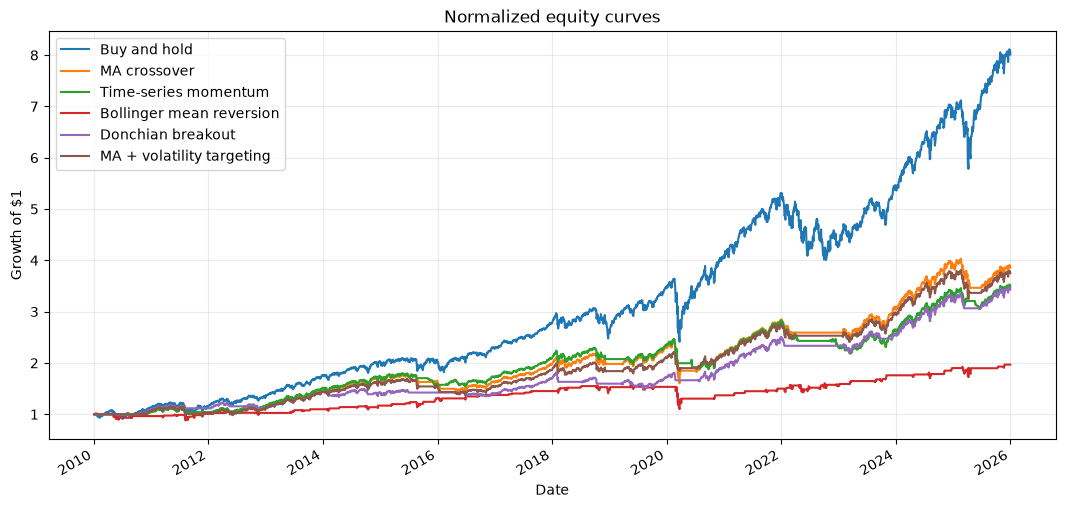

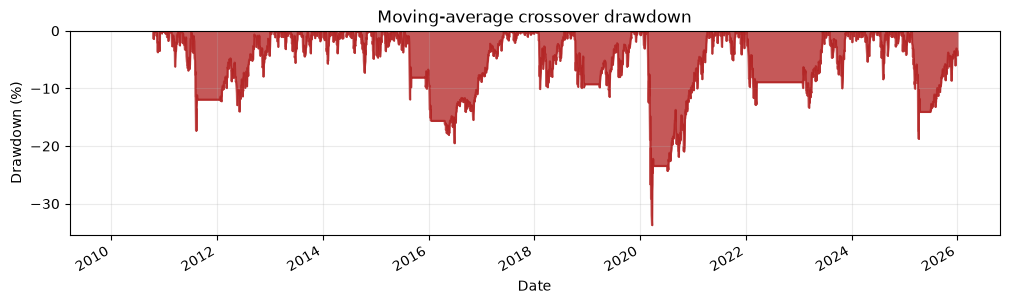

In [5]:
ax = None
for name, result in results.items():
    normalized_equity = result.frame['equity'] / result.frame['equity'].iloc[0]
    ax = normalized_equity.plot(ax=ax, figsize=(13, 6), label=name)
ax.set_title('Normalized equity curves')
ax.set_ylabel('Growth of $1')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

plot_drawdown(results['MA crossover'].frame, title='Moving-average crossover drawdown')
plt.show()

## Cost sensitivity: does the story survive friction?

A result that disappears when the assumed cost changes from 0 to 25 basis points is fragile. This is not a perfect market-impact model, but it is a useful beginner check. Higher-turnover strategies should generally lose more when costs rise.

In [6]:
cost_rows = []
for cost_bps in [0, 5, 10, 25, 50]:
    for name, target in {
        'MA crossover': ma_signal,
        'Bollinger mean reversion': mean_reversion_signal,
        'Donchian breakout': breakout_signal,
    }.items():
        cost_result = run_backtest(close, target, transaction_cost_bps=cost_bps)
        cost_metrics = metrics_for_period(cost_result, splits['test'].index)
        cost_rows.append({
            'strategy': name,
            'cost_bps': cost_bps,
            'test_return': cost_metrics['total_return_after_costs'],
            'test_sharpe': cost_metrics['sharpe_ratio'],
            'annualized_turnover': cost_metrics['annualized_turnover'],
        })

cost_table = pd.DataFrame(cost_rows)
cost_table.style.format({
    'test_return': '{:.2%}',
    'test_sharpe': '{:.2f}',
    'annualized_turnover': '{:.2f}',
})

,strategy,cost_bps,test_return,test_sharpe,annualized_turnover
0,MA crossover,0,49.39%,0.96,0.94
1,Bollinger mean reversion,0,33.21%,0.93,8.45
2,Donchian breakout,0,47.78%,1.18,1.57
3,MA crossover,5,49.16%,0.96,0.94
4,Bollinger mean reversion,5,31.42%,0.88,8.45
5,Donchian breakout,5,47.41%,1.17,1.57
6,MA crossover,10,48.94%,0.96,0.94
7,Bollinger mean reversion,10,29.66%,0.84,8.45
8,Donchian breakout,10,47.04%,1.17,1.57
9,MA crossover,25,48.27%,0.95,0.94


## Small parameter sweep: learn, do not cherry-pick

A parameter is a choice such as “use the last 126 trading days.” If we test hundreds of choices and publish only the best one, the result may be an accident of the historical sample. The following sweep is intentionally small and declared before looking at the test results. It ranks candidates on the validation period, then reports the untouched test result for the validation winner within each strategy family.

This is still not a full probability-of-backtest-overfitting analysis. It is a concrete demonstration of why the test set must be kept separate.

In [7]:
def build_candidate(family, parameters):
    if family == 'MA crossover':
        target = moving_average_signal(close, **parameters)
    elif family == 'Time-series momentum':
        target = time_series_momentum_signal(close, **parameters)
    elif family == 'Bollinger mean reversion':
        target = bollinger_mean_reversion_signal(close, **parameters)
    elif family == 'Donchian breakout':
        target = donchian_breakout_signal(close, high=prices['high'], low=prices['low'], **parameters)
    else:
        raise ValueError(f'Unknown family: {family}')
    return run_backtest(close, target, transaction_cost_bps=TRANSACTION_COST_BPS)

parameter_grid = {
    'MA crossover': [
        {'fast_window': 20, 'slow_window': 100},
        {'fast_window': 50, 'slow_window': 200},
        {'fast_window': 100, 'slow_window': 200},
    ],
    'Time-series momentum': [
        {'lookback': 63, 'long_only': True},
        {'lookback': 126, 'long_only': True},
        {'lookback': 252, 'long_only': True},
    ],
    'Bollinger mean reversion': [
        {'window': 20, 'num_std': 1.5},
        {'window': 20, 'num_std': 2.0},
        {'window': 40, 'num_std': 2.0},
    ],
    'Donchian breakout': [
        {'entry_window': 50, 'exit_window': 20},
        {'entry_window': 100, 'exit_window': 50},
        {'entry_window': 200, 'exit_window': 100},
    ],
}

sweep_rows = []
for family, candidates in parameter_grid.items():
    for parameters in candidates:
        candidate_result = build_candidate(family, parameters)
        train = metrics_for_period(candidate_result, splits['train'].index)
        validation = metrics_for_period(candidate_result, splits['validation'].index)
        test = metrics_for_period(candidate_result, splits['test'].index)
        sweep_rows.append({
            'family': family,
            'parameters': str(parameters),
            'train_sharpe': train['sharpe_ratio'],
            'validation_sharpe': validation['sharpe_ratio'],
            'test_sharpe': test['sharpe_ratio'],
            'test_return': test['total_return_after_costs'],
            'test_max_drawdown': test['max_drawdown'],
        })

sweep_table = pd.DataFrame(sweep_rows)
sweep_table.style.format({
    'train_sharpe': '{:.2f}',
    'validation_sharpe': '{:.2f}',
    'test_sharpe': '{:.2f}',
    'test_return': '{:.2%}',
    'test_max_drawdown': '{:.2%}',
})

,family,parameters,train_sharpe,validation_sharpe,test_sharpe,test_return,test_max_drawdown
0,MA crossover,"{'fast_window': 20, 'slow_window': 100}",0.67,0.49,1.23,55.21%,-10.01%
1,MA crossover,"{'fast_window': 50, 'slow_window': 200}",0.70,0.49,0.96,48.94%,-18.76%
2,MA crossover,"{'fast_window': 100, 'slow_window': 200}",0.67,0.48,1.10,59.63%,-18.76%
3,Time-series momentum,"{'lookback': 63, 'long_only': True}",0.32,0.53,1.26,53.43%,-8.41%
4,Time-series momentum,"{'lookback': 126, 'long_only': True}",0.78,0.42,1.02,43.48%,-11.78%
5,Time-series momentum,"{'lookback': 252, 'long_only': True}",0.55,0.32,1.16,55.57%,-22.71%
6,Bollinger mean reversion,"{'window': 20, 'num_std': 1.5}",0.51,0.04,0.50,16.76%,-11.56%
7,Bollinger mean reversion,"{'window': 20, 'num_std': 2.0}",0.49,0.12,0.84,29.66%,-10.54%
8,Bollinger mean reversion,"{'window': 40, 'num_std': 2.0}",0.67,0.04,0.62,20.45%,-14.59%
9,Donchian breakout,"{'entry_window': 50, 'exit_window': 20}",0.42,0.42,0.70,21.62%,-11.62%


In [8]:
validation_winners = (
    sweep_table.sort_values(['family', 'validation_sharpe'], ascending=[True, False])
    .groupby('family', as_index=False)
    .head(1)
    .reset_index(drop=True)
)
validation_winners.style.format({
    'train_sharpe': '{:.2f}',
    'validation_sharpe': '{:.2f}',
    'test_sharpe': '{:.2f}',
    'test_return': '{:.2%}',
    'test_max_drawdown': '{:.2%}',
})

,family,parameters,train_sharpe,validation_sharpe,test_sharpe,test_return,test_max_drawdown
0,Bollinger mean reversion,"{'window': 20, 'num_std': 2.0}",0.49,0.12,0.84,29.66%,-10.54%
1,Donchian breakout,"{'entry_window': 100, 'exit_window': 50}",0.56,1.24,1.17,47.04%,-8.63%
2,MA crossover,"{'fast_window': 50, 'slow_window': 200}",0.70,0.49,0.96,48.94%,-18.76%
3,Time-series momentum,"{'lookback': 63, 'long_only': True}",0.32,0.53,1.26,53.43%,-8.41%


## Monthly returns and a beginner’s conclusion checklist

Daily returns can hide the experience of holding a strategy. A monthly table makes clusters of gains and losses easier to see. After running the notebook, write a conclusion using evidence from the tables rather than a single attractive metric.

1. Did any strategy beat buy-and-hold after costs in the untouched test period?
2. Did it do so with a smaller drawdown, or did it simply take more risk?
3. Did the result remain positive when costs increased?
4. Did validation-period rankings survive in the test period? If not, that is evidence of instability, not a reason to keep searching until something works.
5. Which market behavior does each rule need: a persistent trend, a stable range, or a temporary price shock?

A strong research conclusion can be negative: “The mean-reversion rule looked attractive in one period but was fragile to costs and did not generalize to the test period.” That is more informative than claiming a strategy is profitable because one backtest had a high Sharpe ratio.

In [9]:
monthly_returns(results['MA crossover'].frame).style.format('{:.2%}', na_rep='')

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2010,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.08%,0.00%,6.69%
2011,2.33%,3.47%,0.01%,2.90%,-1.12%,-1.69%,-2.00%,-7.56%,0.00%,0.00%,0.00%,0.00%
2012,-0.32%,4.34%,3.22%,-0.67%,-6.01%,4.06%,1.18%,2.51%,2.54%,-1.82%,0.57%,0.89%
2013,5.12%,1.28%,3.80%,1.92%,2.36%,-1.33%,5.17%,-3.00%,3.16%,4.63%,2.96%,2.59%
2014,-3.52%,4.55%,0.83%,0.70%,2.32%,2.06%,-1.34%,3.95%,-1.38%,2.36%,2.75%,-0.25%
2015,-2.96%,5.62%,-1.57%,0.98%,1.29%,-2.03%,2.26%,-6.10%,-1.17%,0.00%,0.00%,-0.22%
2016,-7.97%,0.00%,0.00%,-1.89%,1.70%,0.35%,3.65%,0.12%,0.01%,-1.73%,3.68%,2.03%
2017,1.79%,3.93%,0.12%,0.99%,1.41%,0.64%,2.06%,0.29%,2.01%,2.36%,3.06%,1.21%
2018,5.64%,-3.64%,-2.74%,0.52%,2.43%,0.58%,3.70%,3.19%,0.59%,-6.91%,1.85%,-3.79%


## What went well / what went wrong

**What went well:** This notebook puts trend, momentum, mean reversion, and breakout rules under one data split, cost model, metric set, and benchmark. That makes the comparison more credible than comparing isolated headline returns.

**What went wrong:** No strategy should be expected to win in every regime. Trend rules can fail in ranges, mean reversion can fail during persistent trends, and breakout rules can suffer from false signals. A small parameter sweep can also create multiple-testing risk.

The useful conclusion is the strategy-condition map: identify what market behavior each rule needs and where the validation ranking failed to carry into the test period.